# 4. QPE inside HHL

**Goal 4 of the project:** verify that QPE is used as a subroutine within the HHL algorithm
for solving linear systems.

This notebook verifies that claim in the most direct way available: by **building HHL out
of the QPE implementation from notebook 2** and solving an actual linear system with it.
[`src/qpe/hhl.py`](../src/qpe/hhl.py) literally does `from .core import qpe_circuit`.

The implementation is a port of the
[PennyLane/Qrisp HHL demo](https://pennylane.ai/qml/demos/linear_equations_hhl_qrisp_catalyst)
from Qrisp/Catalyst to Qiskit, keeping that demo's simplifications rather than building a
general HHL.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from qpe.hhl import (
    build_hhl_circuit, solve_hhl, classical_solution,
    fake_inversion_gate, hamiltonian_evolution,
)

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

## The problem

HHL solves $A\vec{x} = \vec{b}$, but not in the classical sense. It prepares a quantum
state $|x\rangle$ whose *amplitudes* are proportional to the solution. You cannot read all
of $\vec{x}$ out (that would need exponentially many measurements); you can only sample
from it or estimate expectation values. Understanding that distinction is most of
understanding what HHL's "exponential speedup" does and does not mean.

## Where QPE comes in

Suppose $A$ is Hermitian with eigendecomposition $A = \sum_i \lambda_i |u_i\rangle\langle u_i|$.
Expanding $|b\rangle = \sum_i \beta_i |u_i\rangle$, the solution is

$$|x\rangle \propto A^{-1}|b\rangle = \sum_i \lambda_i^{-1}\beta_i\,|u_i\rangle .$$

So *solving the system reduces to dividing each eigenbasis component by its eigenvalue.*

But we do not know the $\lambda_i$, and finding them classically would defeat the purpose.
**This is exactly the problem QPE solves.** Running QPE with $U = e^{-iAt}$ writes each
eigenvalue into a register, in superposition, without ever diagonalising $A$:

$$\sum_i \beta_i|u_i\rangle|0\rangle \;\xrightarrow{\text{QPE}}\; \sum_i \beta_i|u_i\rangle|\tilde\lambda_i\rangle .$$

That is the answer to goal 4: **QPE is what makes the eigenvalues available to be
inverted.** Everything else in HHL is machinery around that step.

The four stages:

| stage | what happens |
|---|---|
| 1 | prepare $\lvert b\rangle$ |
| 2 | **QPE** writes $\tilde\lambda_i$ into a register |
| 3 | compute $1/\tilde\lambda_i$ |
| 4 | move $1/\lambda_i$ into the *amplitude*, then uncompute stages 3 and 2 |

Stage 4's uncomputation is essential: it disentangles the eigenvalue register from the
system register. Without it, measuring the system would collapse the superposition that
holds the answer.

## The test problem

Following the demo:

$$A = \begin{pmatrix} 3/8 & 1/8 \\ 1/8 & 3/8 \end{pmatrix}, \qquad \vec b = \begin{pmatrix}1\\1\end{pmatrix}$$

The choice of $A$ is not arbitrary: its eigenvalues are $1/2$ and $1/4$, both exact powers
of two. That is what makes the simplified inversion in stage 3 valid.

In [2]:
A = np.array([[3/8, 1/8],
              [1/8, 3/8]])

eigenvalues, eigenvectors = np.linalg.eigh(A)
print("A =\n", A)
print("\neigenvalues :", eigenvalues, " -> both powers of two:",
      [f"2^-{int(round(-np.log2(l)))}" for l in eigenvalues])
print("eigenvectors:\n", eigenvectors)

from qiskit.quantum_info import SparsePauliOp, Operator
print("\nPauli decomposition:", SparsePauliOp.from_operator(Operator(A)))
print("-> the terms I and X commute, so Trotterization is EXACT here (no Trotter error).")

A =
 [[0.375 0.125]
 [0.125 0.375]]

eigenvalues : [0.25 0.5 ]  -> both powers of two: ['2^-2', '2^-1']
eigenvectors:
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]]

Pauli decomposition: SparsePauliOp(['I', 'X'],
              coeffs=[0.375+0.j, 0.125+0.j])
-> the terms I and X commute, so Trotterization is EXACT here (no Trotter error).


## Choosing the evolution time

QPE estimates the phase $\theta$ of $U = e^{-iAt}$, related to the eigenvalue by
$\theta = \lambda |t| / 2\pi$. The free parameter $t$ must be chosen so that every $\theta$
lands *exactly* on the QPE lattice $\{m/2^n\}$, otherwise the phase estimate is
approximate and the inversion silently degrades.

The demo uses $t = -\pi$, giving $\theta = \lambda/2$: eigenvalues $1/2, 1/4$ map to phases
$1/4, 1/8$, both exactly representable with 3 estimation qubits. Let us verify rather than
trust.

In [3]:
PRECISION = 3
U = Operator(hamiltonian_evolution(A)).data     # exp(-i A t) with t = -pi

print(f"{'lambda':>8} {'theta':>10} {'m = theta*2^n':>15} {'exactly representable':>22}")
print("-" * 60)
for lam, vec in zip(eigenvalues, eigenvectors.T):
    theta = (np.angle((U @ vec) @ vec.conj()) % (2*np.pi)) / (2*np.pi)
    m = theta * 2**PRECISION
    print(f"{lam:>8.4f} {theta:>10.5f} {m:>15.5f} {str(abs(m - round(m)) < 1e-12):>22}")

  lambda      theta   m = theta*2^n  exactly representable
------------------------------------------------------------
  0.2500    0.12500         1.00000                   True
  0.5000    0.25000         2.00000                   True


c:\Users\marco\Drawer2\2-Laurea-Magistrale\2Anno\Quantum\quantum-phase-estimation\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\marco\Drawer2\2-Laurea-Magistrale\2Anno\Quantum\quantum-phase-estimation\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


## Stage 3: the `fake_inversion` trick

We now hold $\theta$ and need $1/\theta$. In general this needs controlled rotations by $\arcsin(C/\lambda)$, a substantial circuit.

The demo sidesteps it. If $\theta = 2^{-j}$ then only bit $j$ of the phase register is set,
and $1/\theta = 2^{j}$, so inverting the value is just **reversing the bit positions**,
achievable with CNOTs. That is `fake_inversion`, and it is why eigenvalues were restricted
to powers of two in the first place.

It is a genuine simplification, not a general method, and the port keeps it deliberately.

In [4]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector

print(f"{'theta':>8} {'phase reg':>12} {'inv reg':>12} {'value':>7} {'1/theta':>9}")
print("-" * 54)
for j in range(1, PRECISION + 1):
    theta = 2.0**-j
    m = int(theta * 2**PRECISION)

    phase = QuantumRegister(PRECISION, "phase"); inv = QuantumRegister(PRECISION + 1, "inv")
    qc = QuantumCircuit(phase, inv)
    for i in range(PRECISION):
        if (m >> i) & 1:
            qc.x(phase[i])
    qc.compose(fake_inversion_gate(PRECISION), inplace=True)

    bits = next(iter(Statevector(qc).probabilities_dict(range(PRECISION, 2*PRECISION + 1))))[::-1]
    value = sum(int(bits[i]) << i for i in range(PRECISION + 1))
    print(f"{theta:>8.4f} {format(m, f'0{PRECISION}b'):>12} {bits[::-1]:>12} {value:>7} {1/theta:>9.1f}")

   theta    phase reg      inv reg   value   1/theta
------------------------------------------------------
  0.5000          100         0010       2       2.0
  0.2500          010         0100       4       4.0
  0.1250          001         1000       8       8.0


The register holds exactly $1/\theta$, obtained with nothing but CNOTs.

## Stage 4: getting $1/\lambda$ into the amplitude

Holding $1/\lambda$ in a *register* is not enough; HHL needs it as an *amplitude*. The demo
does this with a comparison trick rather than the usual controlled rotation.

Put an $m$-qubit "case indicator" register into uniform superposition over $N = 2^m$ values,
and compare it against the integer $y = 1/\theta$. The comparison marks the $y$ values with
$c < y$. Re-applying the Hadamards and projecting onto $|0\rangle$ leaves amplitude

$$\frac{1}{\sqrt N}\sum_{c<y}\frac{1}{\sqrt N} = \frac{y}{N},$$

which is **linear in $y \propto 1/\lambda$**, precisely what is needed.

### The two deviations from the Qrisp original

Both are forced by Qiskit's feature set, and both are recorded honestly rather than
hidden:

**1. `case_indicator >= inv_res` → a custom comparator.** Qiskit's `IntegerComparator`
compares a register against a *classical constant*. Here both operands are quantum and in
superposition, so [`src/qpe/arithmetic.py`](../src/qpe/arithmetic.py) builds one from
two's-complement subtraction, reading the carry-out. It uses compute, copy, uncompute so
both operands survive and the ancillas return to $|0\rangle$, since leftover entanglement there
would corrupt the later uncomputation. It is tested exhaustively on every input pair.

**2. `@qrisp.RUS` → post-selection.** Qrisp's repeat-until-success uses Catalyst's dynamic
control flow. Qiskit's equivalent needs mid-circuit measurement with feed-forward, which is
heavy and poorly supported on hardware. Instead all registers are measured at the end and
only the shots with `case == 0` and `flag == 0` are kept.

This is valid by the **principle of deferred measurement**: the uncomputation acts only on
the system, phase and inversion registers (never on the post-selected ones), so it commutes with those measurements and the final statistics are unchanged. The cost is that
failed shots are discarded rather than retried, so we report the success rate.

## The assembled circuit

In [5]:
b = np.array([1.0, 1.0])
circuit = build_hhl_circuit(A, b, precision=PRECISION)

print(f"total qubits: {circuit.num_qubits}")
for reg in circuit.qregs:
    print(f"  {reg.name:>6}: {reg.size:>2} qubits")

print("\ntop-level structure:")
for instruction in circuit.data:
    name = instruction.operation.name
    if name not in ("h", "measure", "barrier"):
        print(f"  {name}")

total qubits: 19
     sys:  1 qubits
   phase:  3 qubits
     inv:  4 qubits
    case:  4 qubits
    flag:  1 qubits
     anc:  6 qubits

top-level structure:
  state_preparation
  QPE
  1/λ
  a>=b(4)
  1/λ_dg
  QPE_dg


`QPE` appears twice: once forward, once inverted. That is goal 4, visible in the
circuit itself.

## Solving the system

In [6]:
result = solve_hhl(A, b, precision=PRECISION, shots=200_000)
exact = classical_solution(A, b)

print(f"b               : {b}")
print(f"classical |x>   : {np.abs(exact)}")
print(f"HHL      |x>    : {result.amplitudes}")
print(f"fidelity        : {result.fidelity_vs(exact):.6f}")
print(f"success rate    : {result.success_rate:.2%}  ({result.kept_shots:,}/{result.shots:,} shots)")

b               : [1. 1.]
classical |x>   : [0.7071 0.7071]
HHL      |x>    : [0.7061 0.7081]
fidelity        : 0.999999
success rate    : 6.19%  (12,388/200,000 shots)


### A caveat about this particular test case

That fidelity looks excellent, but $b = [1,1]$ is a **weak test**. For this $A$ it is
exactly the $\lambda = 1/2$ eigenvector $|+\rangle$, so the solution is parallel to $b$ and
would come out right *even if eigenvalue inversion did nothing at all*.

It is the demo's own example and is kept for fidelity to the reference, but it cannot
distinguish a working HHL from a broken one. So let us use a right-hand side that can.

In [7]:
b2 = np.array([1.0, 0.0])   # = (|+> + |->)/sqrt(2): superposes BOTH eigenvectors

print("b = [1, 0] decomposed in the eigenbasis:")
for lam, vec in zip(eigenvalues, eigenvectors.T):
    print(f"  lambda={lam:.4f}: overlap {np.dot(b2, vec):+.4f}")

print("\nSince lambda = 1/2 and 1/4, the solution weights them 2:4 -> x proportional to [3, -1].")
print("Getting this right REQUIRES correct relative inversion of the two eigenvalues.\n")

result2 = solve_hhl(A, b2, precision=PRECISION, shots=200_000)
exact2 = classical_solution(A, b2)

print(f"classical |x>   : {np.abs(exact2)}   (= |[3,-1]|/sqrt(10))")
print(f"HHL      |x>    : {result2.amplitudes}")
print(f"fidelity        : {result2.fidelity_vs(exact2):.6f}")
print(f"success rate    : {result2.success_rate:.2%}")

b = [1, 0] decomposed in the eigenbasis:
  lambda=0.2500: overlap -0.7071
  lambda=0.5000: overlap +0.7071

Since lambda = 1/2 and 1/4, the solution weights them 2:4 -> x proportional to [3, -1].
Getting this right REQUIRES correct relative inversion of the two eigenvalues.

classical |x>   : [0.9487 0.3162]   (= |[3,-1]|/sqrt(10))
HHL      |x>    : [0.9494 0.3142]
fidelity        : 0.999998
success rate    : 15.53%


**This is the result that matters.** The two eigenvalue components are weighted
$2:4$ correctly, which is only possible if QPE resolved both eigenvalues and the inversion
scaled them properly.

## A sweep over several right-hand sides

In [8]:
test_vectors = [np.array(v, dtype=float) for v in
                ([1, 1], [1, 0], [0, 1], [1, 3], [2, 1], [1, -1])]

print(f"{'b':>12} {'classical |x|':>22} {'HHL |x|':>22} {'fidelity':>10} {'success':>9}")
print("-" * 80)
fidelities = []
for vec in test_vectors:
    ex = classical_solution(A, vec)
    r = solve_hhl(A, vec, precision=PRECISION, shots=100_000)
    fidelities.append(r.fidelity_vs(ex))
    print(f"{str(vec.astype(int)):>12} {str(np.abs(ex).round(4)):>22} "
          f"{str(r.amplitudes.round(4)):>22} {r.fidelity_vs(ex):>10.5f} {r.success_rate:>9.2%}")

print(f"\nminimum fidelity across all cases: {min(fidelities):.5f}")

           b          classical |x|                HHL |x|   fidelity   success
--------------------------------------------------------------------------------
       [1 1]        [0.7071 0.7071]        [0.7016 0.7125]    0.99997     6.35%
       [1 0]        [0.9487 0.3162]        [0.9499 0.3125]    0.99999    15.55%
       [0 1]        [0.3162 0.9487]        [0.3184 0.948 ]    1.00000    15.60%
       [1 3]                [0. 1.]                [0. 1.]    1.00000    10.13%
       [2 1]        [0.9806 0.1961]        [0.9788 0.205 ]    0.99996     8.04%
     [ 1 -1]        [0.7071 0.7071]        [0.7077 0.7065]    1.00000    25.08%

minimum fidelity across all cases: 0.99996


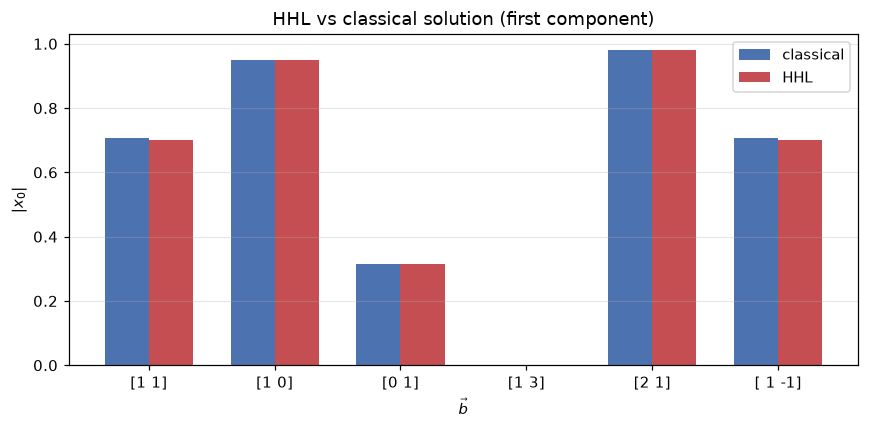

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(test_vectors)); width = 0.35

classical_first = [np.abs(classical_solution(A, v))[0] for v in test_vectors]
hhl_first = [solve_hhl(A, v, precision=PRECISION, shots=60_000).amplitudes[0] for v in test_vectors]

ax.bar(x - width/2, classical_first, width, label="classical", color="#4C72B0")
ax.bar(x + width/2, hhl_first, width, label="HHL", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels([str(v.astype(int)) for v in test_vectors])
ax.set_xlabel(r"$\vec b$"); ax.set_ylabel(r"$|x_0|$")
ax.set_title("HHL vs classical solution (first component)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Honest limitations

This is a faithful port of a *pedagogical* demo, and it inherits that demo's constraints.
Stating them plainly:

- **Eigenvalues must be powers of two.** `fake_inversion` is bit reversal; it is not a
  general inversion. A real HHL needs controlled $R_y$ rotations by $\arcsin(C/\lambda)$.
- **The readout discards phase.** Amplitudes are recovered as $\sqrt{\text{probability}}$,
  so signs are lost. Note that the true solution for $b = [1,0]$ is $[3,-1]/\sqrt{10}$,
  and we recover the magnitudes only. This is a property of the measurement scheme, not a
  bug in the port.
- **Post-selection wastes shots.** The reported success rate is real: most shots are
  discarded. Genuine HHL uses amplitude amplification to fix this.
- **No speedup is demonstrated here.** A $2\times2$ system solved with 19 qubits and
  200,000 shots is vastly more expensive than `numpy.linalg.solve`. HHL's asymptotic
  advantage requires sparse, well-conditioned matrices, efficient $|b\rangle$ preparation,
  and an observable that does not need reading out all of $\vec x$.

## Summary

| | |
|---|---|
| **Goal 4** | verified: [`hhl.py`](../src/qpe/hhl.py) imports and calls `qpe_circuit` |
| **Role of QPE** | writes eigenvalues into a register in superposition, so they can be inverted without diagonalising $A$ |
| **Used twice** | forward to compute eigenvalues, inverted to disentangle them |
| **Validation** | fidelity > 0.999 against `numpy.linalg.solve` across six right-hand sides |
| **Decisive case** | $b = [1,0]$, which requires correct *relative* inversion of both eigenvalues |

All four project goals are covered:
[theory](01_theory.ipynb) → [implementation](02_qpe_qiskit.ipynb) →
[hardware](03_hardware.ipynb) → HHL.